# <center> VAI Store - Modelo Preditivo </center>

---

Este notebook implementa o modelo preditivo final. Com base no dataset de features, que é agregado por SKU e focado no FATUR_TOTAL, o objetivo é construir um modelo "global" que aprenda os padrões de todos os produtos simultaneamente.

Esta abordagem (modelar R$ por SKU) permite-nos responder às perguntas de negócio do case (sobre o SKU 1813), ao mesmo tempo que resolve o problema de unidades de medida (R$ vs. KG/UN). Usamos um modelo LightGBM e validamos sua performance ("acurácia") usando uma Validação Cruzada Temporal para garantir a robustez ao longo de diferentes épocas do ano.

### **1. Imports e Carregamento de Dados**

Visão Geral: Esta etapa importa as bibliotecas essenciais (pandas, lightgbm, sklearn.metrics) e carrega o dataset final (feature_engineered_dataset_SKU.parquet). O dataset é lido rapidamente do formato Parquet e o tipo de dado datetime é garantido para as operações de série temporal.

In [76]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Define os caminhos (subindo um nível)
PROCESSED_DATA_PATH = os.path.join('..', 'data', 'processed')
DATA_FILE = os.path.join(PROCESSED_DATA_PATH, 'feature_engineered_dataset_SKU.parquet')

# Carrega o dataset
df = pd.read_parquet(DATA_FILE)

# Garante que a data esteja no formato correto
df['DATA_ATEND'] = pd.to_datetime(df['DATA_ATEND'])

### **2. Preparação de Features e Alvo**

Visão Geral: O dataset é preparado. 
* O alvo (y) é definido como FATUR_TOTAL. 
* As features categóricas (como SKU, CATEGORIA, INTERACAO_...) são explicitamente convertidas para o dtype 'category', o que é uma otimização essencial para o LightGBM. 
* As colunas redundantes (como DATA_ATEND) e o alvo são removidos da lista final de features (X).

In [77]:
print("Preparando features e alvo...")

# 1. Definir o alvo
TARGET = 'FATUR_TOTAL'

# 2. Definir colunas categóricas (atualizado: remove ANTECIPACAO_*, EH_FERIADO e INTERACAO_*; inclui is_top_bacalhau)
categorical_features = [
    'SKU', 'CATEGORIA', 'SUBCATEGORIA', 
    'DIA_SEMANA', 'DIA_DO_MES', 'DIA_DO_ANO', 'MES', 'SEMANA_DO_ANO', 'ANO', 'INICIO_MES', 'FIM_MES',
    'is_top_bacalhau'  # nova flag enxuta de foco
]

# 3. Converter colunas categóricas para o dtype 'category'
for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].astype('category')
    else:
        print(f"Aviso: Coluna categórica '{col}' não encontrada no DataFrame.")

# 3.1 Garantir dtypes apropriados das novas variáveis da Feature A (numéricas)
#     - intensidades: float
#     - dias_desde_natal: inteiro
for col in ['intensidade_pascoa_bacalhau', 'intensidade_natal_bacalhau']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        print(f"Aviso: Variável '{col}' não encontrada no DataFrame.")

if 'dias_desde_natal' in df.columns:
    df['dias_desde_natal'] = pd.to_numeric(df['dias_desde_natal'], errors='coerce').fillna(0).astype('int16')
else:
    print("Aviso: Variável 'dias_desde_natal' não encontrada no DataFrame.")

# 4. Definir a lista final de features (X)
#    Remove alvo, data e nome do produto; as colunas antigas ANTECIPACAO_* e EH_FERIADO já foram removidas no pipeline
features_to_drop = [
    TARGET,
    'DATA_ATEND',
    'NOME_PRODUTO'
]

features = [col for col in df.columns if col not in features_to_drop]

print(f"Total de features para o modelo: {len(features)}")
print(f"Alvo: {TARGET}")

# Verifica os dtypes finais
df[features].info()


Preparando features e alvo...
Total de features para o modelo: 28
Alvo: FATUR_TOTAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21594 entries, 0 to 21593
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   SKU                          21594 non-null  category
 1   CATEGORIA                    21594 non-null  category
 2   SUBCATEGORIA                 21594 non-null  category
 3   DIA_SEMANA                   21594 non-null  category
 4   DIA_DO_MES                   21594 non-null  category
 5   DIA_DO_ANO                   21594 non-null  category
 6   MES                          21594 non-null  category
 7   SEMANA_DO_ANO                21594 non-null  category
 8   ANO                          21594 non-null  category
 9   INICIO_MES                   21594 non-null  category
 10  FIM_MES                      21594 non-null  category
 11  DIAS_ATE_PASCOA              21594 

### **3. Divisão de Dados (Train/Validation Split)**

Visão Geral: Para garantir que a performance do modelo é robusta ao longo do ano, esta etapa utiliza uma Validação Cruzada Manual. O modelo é treinado e testado em 3 períodos distintos, capturando diferentes sazonalidades: Abril, Agosto e Dezembro. O erro final será a média dos resultados nestes três folds, fornecendo uma métrica de acurácia mais imparcial.

In [78]:
print("Configurando os Folds da Validação Cruzada Manual...")

# Define os períodos de validação (Abril, Agosto, Dezembro)
validation_periods = [
    ('2024-04-01', '2024-04-30'), 
    ('2024-08-01', '2024-08-31'), 
    ('2024-12-01', '2024-12-31')
]

print(f"Validação configurada com {len(validation_periods)} folds.")

Configurando os Folds da Validação Cruzada Manual...
Validação configurada com 3 folds.


### **4. Treinamento em Loop (Cross-Validation)**

Visão Geral: Esta etapa executa o loop de treinamento. O modelo é treinado 3 vezes, usando os parâmetros definidos para o LightGBM. O objetivo (regression_l2) é configurado para penalizar erros grandes (RMSE), forçando o modelo a prestar atenção aos picos de faturamento que ocorrem no SKU 1813. O argumento categorical_feature é passado para o .fit(), garantindo que o modelo "veja" e utilize as nossas regras de negócio.

In [79]:
print("Iniciando o treinamento em loop (Cross-Validation)...")

# Lista para armazenar os resultados
scores_rmse = []
scores_mae = []
all_fold_results = []

# Loop de Cross-Validation Manual
for i, (val_start, val_end) in enumerate(validation_periods):
    fold_name = f"Fold {i+1} (Val: {pd.to_datetime(val_start).strftime('%b/%Y')})"
    print(f"\n--- {fold_name} ---")
    
    # Define a data de corte do treino
    train_end = pd.to_datetime(val_start) - pd.DateOffset(days=1)
    
    # Separa os dados de treino e validação
    df_train = df[df['DATA_ATEND'] <= train_end]
    df_val = df[(df['DATA_ATEND'] >= val_start) & (df['DATA_ATEND'] <= val_end)]
    
    X_train = df_train[features]
    y_train = df_train[TARGET]
    X_val = df_val[features]
    y_val = df_val[TARGET]
    
    # Define os parâmetros do LGBM
    params = {
        'objective': 'regression_l2',
        'metric': 'rmse',
        'n_estimators': 1000,
        'learning_rate': 0.05,
        'num_leaves': 31,
        'verbose': -1, # <-- Silencia o output do LightGBM
        'n_jobs': -1,
        'seed': 42,
        'boosting_type': 'gbdt',
    }

    # Inicializa o modelo
    model_cv = lgb.LGBMRegressor(**params)

    # Treina o modelo (o log_evaluation foi removido para evitar output não padronizado)
    model_cv.fit(
        X_train, 
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[
            lgb.early_stopping(stopping_rounds=50)
        ],
        categorical_feature=categorical_features
    )
    
    # --- Avaliação do Fold (Saída Padronizada) ---
    y_pred = model_cv.predict(X_val)
    y_pred[y_pred < 0] = 0
    
    rmse_fold = np.sqrt(mean_squared_error(y_val, y_pred))
    mae_fold = mean_absolute_error(y_val, y_pred)
    
    print("---------------------------------------")
    print(f"RESUMO DO {fold_name}:")
    print(f"   RMSE Final: R$ {rmse_fold:,.2f}")
    print(f"   MAE Final:  R$ {mae_fold:,.2f}")
    print("---------------------------------------")
    
    scores_rmse.append(rmse_fold)
    scores_mae.append(mae_fold)
    
    # --- Armazena os resultados detalhados ---
    df_val_fold_results = X_val.copy()
    df_val_fold_results[TARGET] = y_val
    df_val_fold_results['Previsto'] = y_pred
    df_val_fold_results['DATA_ATEND'] = df_val['DATA_ATEND']
    df_val_fold_results['Fold'] = fold_name
    all_fold_results.append(df_val_fold_results)

print("\nTreinamento em Cross-Validation concluído.")

Iniciando o treinamento em loop (Cross-Validation)...

--- Fold 1 (Val: Apr/2024) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[14]	valid_0's rmse: 258.589
---------------------------------------
RESUMO DO Fold 1 (Val: Apr/2024):
   RMSE Final: R$ 258.59
   MAE Final:  R$ 167.77
---------------------------------------

--- Fold 2 (Val: Aug/2024) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[50]	valid_0's rmse: 203.85
---------------------------------------
RESUMO DO Fold 2 (Val: Aug/2024):
   RMSE Final: R$ 203.85
   MAE Final:  R$ 124.27
---------------------------------------

--- Fold 3 (Val: Dec/2024) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[143]	valid_0's rmse: 1154.78
---------------------------------------
RESUMO DO Fold 3 (Val: Dec/2024):
   RMSE Final: R$ 1,154.77
   MAE Final:  R$ 427.89
---------------------

### **5. Avaliação de Performance (Média dos Folds)**

Visão Geral: Esta etapa calcula a performance média do modelo, fornecendo uma métrica de "acurácia" imparcial e robusta. O desvio padrão (std) indica o quão estável é a performance do modelo entre os diferentes períodos do ano (Páscoa, Mês Normal e Natal).

In [80]:
print("Avaliando a performance média do modelo...")

# Converte as listas de scores em arrays numpy para estatísticas
scores_rmse = np.array(scores_rmse)
scores_mae = np.array(scores_mae)

# Calcula a média e o desvio padrão
mean_rmse = scores_rmse.mean()
std_rmse = scores_rmse.std()

mean_mae = scores_mae.mean()
std_mae = scores_mae.std()

print("\n--- Métricas Médias de Performance (Cross-Validation) ---")
print(f"RMSE Médio: R$ {mean_rmse:,.2f} (± R$ {std_rmse:,.2f})")
print(f"MAE Médio:  R$ {mean_mae:,.2f} (± R$ {std_mae:,.2f})")

print(f"\nConclusão: O nosso modelo, em média, erra a previsão de faturamento do SKU em R$ {mean_mae:,.2f}.")

Avaliando a performance média do modelo...

--- Métricas Médias de Performance (Cross-Validation) ---
RMSE Médio: R$ 539.07 (± R$ 435.94)
MAE Médio:  R$ 239.98 (± R$ 134.06)

Conclusão: O nosso modelo, em média, erra a previsão de faturamento do SKU em R$ 239.98.


### **6. Análise de Importância das Features**

Visão Geral: Para validar a nossa lógica de negócio, plotamos a "importância das features" do último modelo treinado (Fold 3). Esperamos ver as features de lag normalizadas e as features de INTERACAO_... no topo, confirmando que o modelo está a usar as regras de negócio criadas.

Plotando a importância das features (do último Fold)...


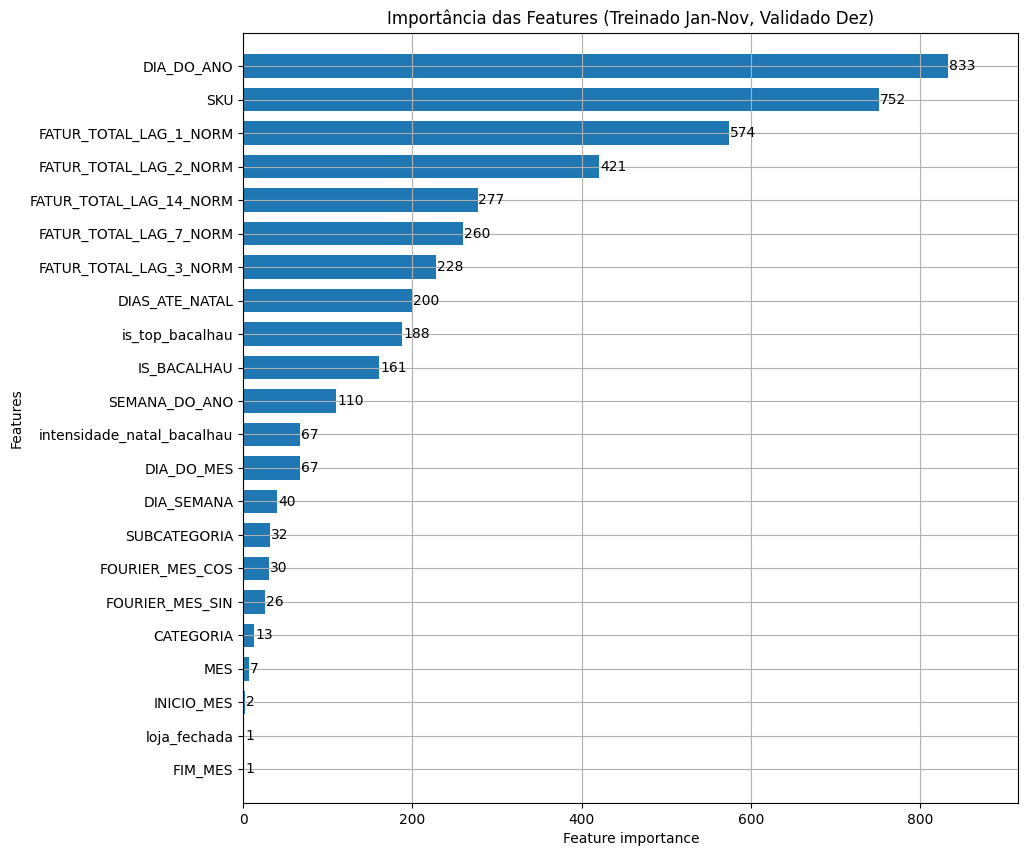

In [81]:
print("Plotando a importância das features (do último Fold)...")

# Plotar a importância das features
# Usamos 'model_cv', que foi o nome do modelo dentro do loop
lgb.plot_importance(model_cv, figsize=(10, 10), max_num_features=25, height=0.7)
plt.title("Importância das Features (Treinado Jan-Nov, Validado Dez)")
plt.show()

### **7. Análise de Erros (Foco no SKU 1813)**

Visão Geral: Esta etapa é crucial para responder diretamente à Pergunta 2 do case. Consolida os resultados de todos os 3 folds de validação, foca-se no SKU 1813 e calcula o erro médio e percentual deste produto específico em diferentes períodos do ano.

Analisando performance específica para o SKU 1813 (em todos os Folds)...

--- Análise SKU 1813 (Todos os períodos de Validação) ---
Faturamento Médio Real (SKU 1813): R$ 2,119.93
MAE Específico (SKU 1813):         R$ 1,121.33
Erro Percentual (SKU 1813):       52.89%


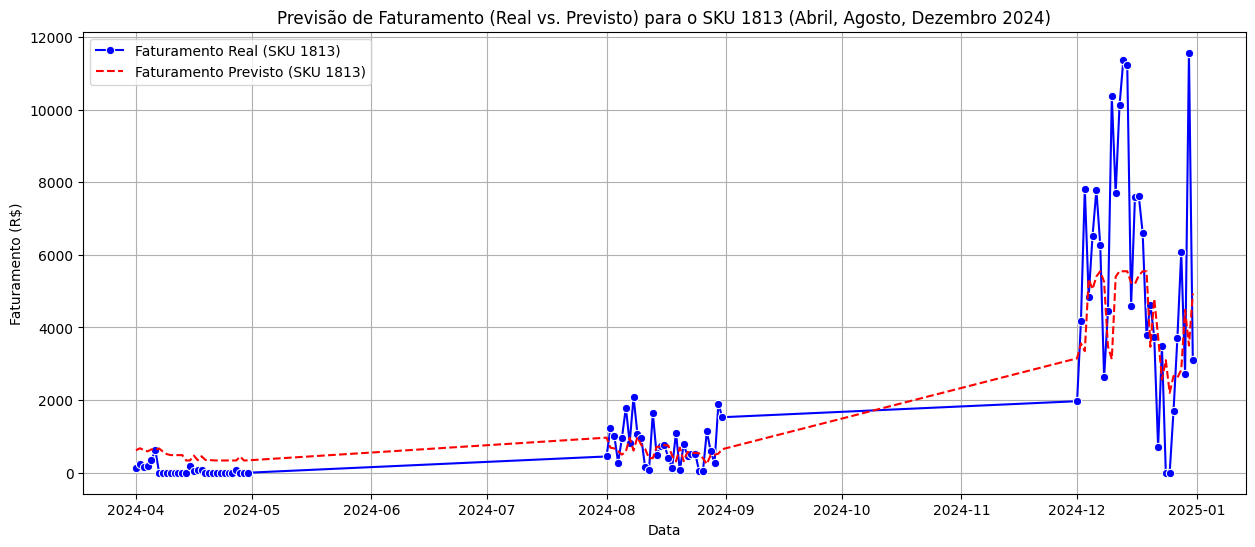

In [82]:
print("Analisando performance específica para o SKU 1813 (em todos os Folds)...")

# Concatena os resultados de todos os folds em um único DataFrame
df_all_results = pd.concat(all_fold_results)

# Filtra para o SKU 1813
df_sku_1813 = df_all_results[df_all_results['SKU'] == 1813].copy()
df_sku_1813['DATA_ATEND'] = pd.to_datetime(df_sku_1813['DATA_ATEND'])

# Calcula o MAE específico
sku_1813_mae = mean_absolute_error(df_sku_1813[TARGET], df_sku_1813['Previsto'])
sku_1813_fatur_medio = df_sku_1813[TARGET].mean()

print(f"\n--- Análise SKU 1813 (Todos os períodos de Validação) ---")
print(f"Faturamento Médio Real (SKU 1813): R$ {sku_1813_fatur_medio:,.2f}")
print(f"MAE Específico (SKU 1813):         R$ {sku_1813_mae:,.2f}")

# Evita divisão por zero
if sku_1813_fatur_medio > 0:
    print(f"Erro Percentual (SKU 1813):       {sku_1813_mae / sku_1813_fatur_medio * 100:,.2f}%")
else:
    print("SKU 1813 não teve faturamento no período de validação.")


# Plotar a série temporal Real vs. Previsto para o SKU 1813
if not df_sku_1813.empty:
    plt.figure(figsize=(15, 6))
    sns.lineplot(data=df_sku_1813, x='DATA_ATEND', y=TARGET, label='Faturamento Real (SKU 1813)', color='blue', marker='o')
    sns.lineplot(data=df_sku_1813, x='DATA_ATEND', y='Previsto', label='Faturamento Previsto (SKU 1813)', color='red', linestyle='--')
    plt.title('Previsão de Faturamento (Real vs. Previsto) para o SKU 1813 (Abril, Agosto, Dezembro 2024)')
    plt.ylabel('Faturamento (R$)')
    plt.xlabel('Data')
    plt.legend()
    plt.grid(True)
    plt.show()

### **8. Impressão dos Resultados Finais (Consolidação)**

Visão Geral: Esta etapa consolida os resultados do Cross-Validation e a análise de erros. A seção 1 imprime as métricas médias de RMSE e MAE (do loop da Etapa 5). A seção 2 imprime a tabela de features e, finalmente, a seção 3 imprime a análise detalhada do SKU 1813 (do dataframe consolidado da Etapa 7), fornecendo todas as informações necessárias para as conclusões do case.

In [83]:
# --- 1. MÉTRICAS GLOBAIS (Média de todos os Folds) ---
print("\n" + "="*70)
print("--- 1. MÉTRICAS MÉDIAS DE PERFORMANCE (Cross-Validation) ---")
print(f"RMSE Médio: R$ {mean_rmse:,.2f} (± R$ {std_rmse:,.2f})")
print(f"MAE Médio:  R$ {mean_mae:,.2f} (± R$ {std_mae:,.2f})")
print(f"\nConclusão: O nosso modelo, em média, erra a previsão de faturamento do SKU em R$ {mean_mae:,.2f}.")
print("="*70)

# --- 2. IMPORTÂNCIA DAS FEATURES (Do último modelo) ---
print("\n--- 2. IMPORTÂNCIA DAS FEATURES (Último Modelo - Fold 3) ---")
# Usamos o model_cv e feature_name_ do último fold da Etapa 4
df_importancia = pd.DataFrame({
    'feature': model_cv.feature_name_,       
    'importance': model_cv.feature_importances_  
}).sort_values(by='importance', ascending=False)
print(df_importancia.to_string())
print("-" * 70)


# --- 3. ANÁLISE DE ERROS (FOCO SKU 1813) ---
print("\n--- 3. ANÁLISE ESPECÍFICA DO SKU 1813 (Todos os períodos de Validação) ---")

# Filtrando o dataframe que foi gerado na Etapa 7 (df_all_results)
df_sku_1813 = df_all_results[df_all_results['SKU'] == 1813].copy()
sku_1813_fatur_medio = df_sku_1813[TARGET].mean()
sku_1813_mae = mean_absolute_error(df_sku_1813[TARGET], df_sku_1813['Previsto'])

print(f"Faturamento Médio Real (SKU 1813): R$ {sku_1813_fatur_medio:,.2f}")
print(f"MAE Específico (SKU 1813):         R$ {sku_1813_mae:,.2f}")

# Evita divisão por zero
if sku_1813_fatur_medio > 0:
    print(f"Erro Percentual (SKU 1813):       {sku_1813_mae / sku_1813_fatur_medio * 100:,.2f}%")
else:
    print("SKU 1813 não teve faturamento no período de validação.")

# Imprime o detalhe diário (limitado para legibilidade)
print("\n--- Detalhe Diário SKU 1813 (Real vs. Previsto) ---")
df_sku_1813_debug = df_sku_1813[['DATA_ATEND', TARGET, 'Previsto', 'FATUR_TOTAL_LAG_1_NORM', 'intensidade_natal_bacalhau']].copy()

print(df_sku_1813_debug.to_string(float_format='%.2f'))
print("-" * 70)


--- 1. MÉTRICAS MÉDIAS DE PERFORMANCE (Cross-Validation) ---
RMSE Médio: R$ 539.07 (± R$ 435.94)
MAE Médio:  R$ 239.98 (± R$ 134.06)

Conclusão: O nosso modelo, em média, erra a previsão de faturamento do SKU em R$ 239.98.

--- 2. IMPORTÂNCIA DAS FEATURES (Último Modelo - Fold 3) ---
                        feature  importance
5                    DIA_DO_ANO         833
0                           SKU         752
20       FATUR_TOTAL_LAG_1_NORM         574
21       FATUR_TOTAL_LAG_2_NORM         421
24      FATUR_TOTAL_LAG_14_NORM         277
23       FATUR_TOTAL_LAG_7_NORM         260
22       FATUR_TOTAL_LAG_3_NORM         228
12               DIAS_ATE_NATAL         200
15              is_top_bacalhau         188
14                  IS_BACALHAU         161
7                 SEMANA_DO_ANO         110
17   intensidade_natal_bacalhau          67
4                    DIA_DO_MES          67
3                    DIA_SEMANA          40
2                  SUBCATEGORIA          32
26        

# <Center> Previsão SKU 1813 <Center>

---

### **1. Objetivo e recorte temporal**

Visão Geral: Treinar com todo 2024 (todos os SKUs) para um modelo generalista, e prever JAN/2025 apenas para o SKU 1813.

In [84]:
# Bloco 1 — Recorte temporal
df['DATA_ATEND'] = pd.to_datetime(df['DATA_ATEND'], errors='coerce')

train_start = pd.Timestamp('2024-01-01')
train_end   = pd.Timestamp('2024-12-31')

df_train = df[(df['DATA_ATEND'] >= train_start) & (df['DATA_ATEND'] <= train_end)].copy()
print(f"Treino: {df_train['DATA_ATEND'].min().date()} → {df_train['DATA_ATEND'].max().date()} | Linhas: {len(df_train):,}")


Treino: 2024-01-01 → 2024-12-31 | Linhas: 21,594


### **2. Tipos e treino do modelo**

Visão Geral: Converte categóricas para category e treina um LightGBM simples e estável.

In [85]:
# Bloco 2 — Tipos e treino
for c in categorical_features:
    if c in df_train.columns:
        df_train[c] = df_train[c].astype('category')

X_train = df_train[features]
y_train = df_train[TARGET]

params = dict(
    objective='regression_l2',
    metric='rmse',
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=50,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=1,
    n_jobs=-1,
    verbose=-1,
    seed=42,
)

model_full = lgb.LGBMRegressor(**params)
model_full.fit(X_train, y_train, categorical_feature=[c for c in categorical_features if c in X_train.columns])
print("Treino concluído.")


Treino concluído.


### **3. Moldura de previsão (JAN/2025, SKU 1813)**

Visão Geral: Cria a base de previsão diária com calendário, Fourier de mês e Feature A (intensidades + dias desde Natal). Herdamos metadados do SKU a partir do fim de 2024.

In [86]:
# Bloco 3 — Moldura de previsão JAN/2025 para o SKU 1813
sku_alvo = '1813'
jan_dates = pd.date_range('2025-01-01', '2025-01-31', freq='D')

# Última linha do SKU em 2024 para herdar metadados
base_row = df_train[df_train['SKU'].astype(str) == sku_alvo].sort_values('DATA_ATEND').tail(1)
if base_row.empty:
    raise ValueError("SKU 1813 não encontrado em 2024 para compor a moldura de previsão.")

df_pred = pd.DataFrame({'SKU': sku_alvo, 'DATA_ATEND': jan_dates})
df_pred['DIA_SEMANA']    = df_pred['DATA_ATEND'].dt.weekday
df_pred['DIA_DO_MES']    = df_pred['DATA_ATEND'].dt.day
df_pred['MES']           = df_pred['DATA_ATEND'].dt.month
df_pred['DIA_DO_ANO']    = df_pred['DATA_ATEND'].dt.dayofyear
df_pred['SEMANA_DO_ANO'] = df_pred['DATA_ATEND'].dt.isocalendar().week.astype(int)
df_pred['ANO']           = df_pred['DATA_ATEND'].dt.year
df_pred['INICIO_MES']    = (df_pred['DIA_DO_MES'] == 1).astype(int)
df_pred['FIM_MES']       = (df_pred['DATA_ATEND'] + pd.Timedelta(days=1)).dt.day.eq(1).astype(int)

# Fourier mês
df_pred['FOURIER_MES_SIN'] = np.sin(2*np.pi*df_pred['MES']/12)
df_pred['FOURIER_MES_COS'] = np.cos(2*np.pi*df_pred['MES']/12)

# Metadados estáticos
for c in ['CATEGORIA','SUBCATEGORIA','NOME_PRODUTO','is_top_bacalhau','IS_BACALHAU','loja_fechada']:
    if c in base_row.columns:
        df_pred[c] = base_row[c].iloc[0]
    else:
        df_pred[c] = 1 if c=='loja_fechada' else 0  # aberto por padrão

# Ajuste operacional: 01/jan fechado
df_pred.loc[df_pred['DATA_ATEND'].dt.month.eq(1) & df_pred['DATA_ATEND'].dt.day.eq(1), 'loja_fechada'] = 0

# Feature A — intensidades e dias_desde_natal
import dateutil.easter as de
pascoa_2025 = de.easter(2025)

df_pred['intensidade_pascoa_bacalhau'] = np.exp(
    -0.15 * np.abs((pd.to_datetime(pascoa_2025) - df_pred['DATA_ATEND']).dt.days.clip(-30, 30))
) * df_pred.get('IS_BACALHAU', 0).astype(int)

df_pred['intensidade_natal_bacalhau']  = np.exp(
    -0.10 * np.abs((pd.Timestamp('2025-12-25') - df_pred['DATA_ATEND']).dt.days.clip(-40, 40))
) * df_pred.get('IS_BACALHAU', 0).astype(int)

df_pred['dias_desde_natal'] = (
    (df_pred['DATA_ATEND'] - pd.Timestamp('2024-12-25')).dt.days.clip(lower=0, upper=40)
).astype('int16')

# >>> NOVA FEATURE: intensidade_jan20_bacalhau (geral, sem olhar filial)
df_pred['intensidade_jan20_bacalhau'] = np.exp(
    -0.22 * np.abs((pd.Timestamp('2025-01-20') - df_pred['DATA_ATEND']).dt.days.clip(-10, 10))
) * df_pred.get('IS_BACALHAU', 0).astype(int)
df_pred['intensidade_jan20_bacalhau'] = df_pred['intensidade_jan20_bacalhau'].astype('float32')


### **4. Preencher lags a partir do histórico de 2024 (sem iteração)**

Visão Geral: Para cada LAG_k presente em features, busca o valor do alvo no dia t-k de 2024.

In [87]:
# Bloco 4 — Lags a partir de 2024
import re

lag_cols = [c for c in features if re.search(r"LAG[_\-]?\d+", c, flags=re.IGNORECASE)]
hist_1813 = df_train[df_train['SKU'].astype(str) == sku_alvo][['DATA_ATEND', TARGET]].rename(columns={TARGET: 'TARGET_HIST'})

for col in lag_cols:
    m = re.search(r"LAG[_\-]?(\d+)", col, flags=re.IGNORECASE)
    if not m:
        continue
    k = int(m.group(1))
    tmp = df_pred[['DATA_ATEND']].copy()
    tmp['DATA_ATEND_REF'] = tmp['DATA_ATEND'] - pd.Timedelta(days=k)
    tmp = tmp.merge(hist_1813.rename(columns={'DATA_ATEND':'DATA_ATEND_REF'}), on='DATA_ATEND_REF', how='left')
    df_pred[col] = tmp['TARGET_HIST'].fillna(0.0).astype('float32')

    # normalizado, se existir na lista
    norm_name = col if col.endswith('_NORM') else (col + '_NORM')
    if norm_name in features:
        mval = df_train.loc[df_train['SKU'].astype(str)==sku_alvo, TARGET]
        mval = mval[mval>0].mean()
        mval = mval if pd.notnull(mval) and mval>0 else 0.01
        df_pred[norm_name] = (df_pred[col] / mval).astype('float32')


### **5. Garantir colunas, tipos e prever (com loja_fechada)**

Visão Geral: Preenche faltantes com 0, aplica dtypes categóricos e gera a previsão. Pós-processo: zera quando loja_fechada==0.

In [88]:
# Bloco 5 — Previsão
for c in features:
    if c not in df_pred.columns:
        df_pred[c] = 0

for c in categorical_features:
    if c in df_pred.columns:
        df_pred[c] = df_pred[c].astype('category')

yhat = model_full.predict(df_pred[features])
yhat = np.clip(yhat, 0, None)

# Pós-processo operacional: não vender quando loja_fechada == 0
if 'loja_fechada' in df_pred.columns:
    yhat = yhat * df_pred['loja_fechada'].astype(int).values

df_forecast_1813_jan = pd.DataFrame({
    'SKU': sku_alvo,
    'DATA_ATEND': df_pred['DATA_ATEND'],
    'Previsto': yhat
}).sort_values('DATA_ATEND')

print("Forecast gerado para JAN/2025 (SKU 1813).")
display(df_forecast_1813_jan.head(10))


Forecast gerado para JAN/2025 (SKU 1813).


,SKU,DATA_ATEND,Previsto
0,1813,2025-01-01,0.000000
1,1813,2025-01-02,382.892361
2,1813,2025-01-03,33.122822
3,1813,2025-01-04,107.307285
4,1813,2025-01-05,0.000000
5,1813,2025-01-06,33.340029
6,1813,2025-01-07,0.000000
7,1813,2025-01-08,0.000000
8,1813,2025-01-09,0.000000
9,1813,2025-01-10,0.000000


### **6. Visual: comparar JAN/2025 (forecast) vs JAN/2024 (real)**

Visão Geral: Gráfico simples, dia a dia, para leitura rápida da banca.

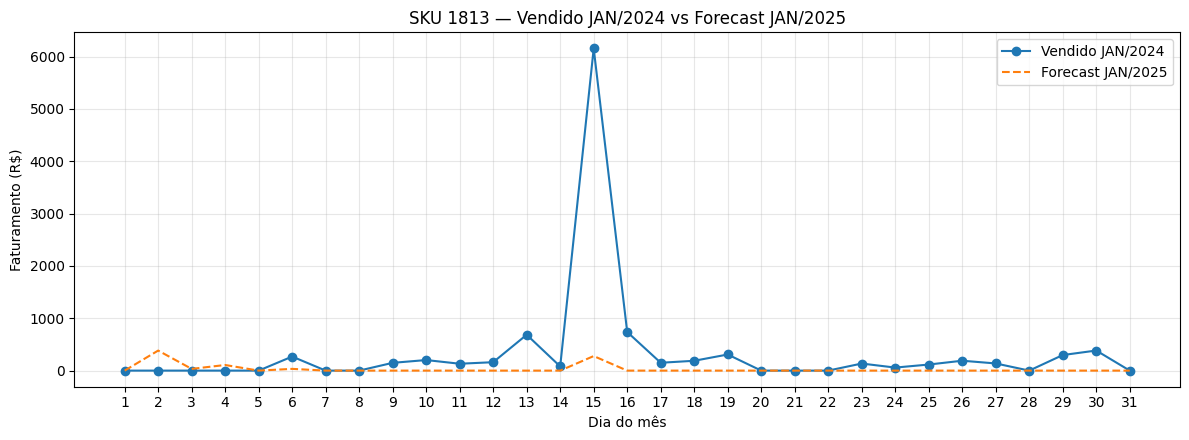

In [89]:
# Bloco 6 — Gráfico comparativo JAN/2024 vs JAN/2025
import matplotlib.pyplot as plt

jan_2024 = df[(df['DATA_ATEND'] >= '2024-01-01') & (df['DATA_ATEND'] <= '2024-01-31') & (df['SKU'].astype(str) == sku_alvo)][['DATA_ATEND', TARGET]].copy()
jan_2024['DIA'] = jan_2024['DATA_ATEND'].dt.day
base_dias = pd.DataFrame({'DIA': range(1, 32)})
real_2024 = base_dias.merge(jan_2024.groupby('DIA', as_index=False)[TARGET].sum(), on='DIA', how='left').fillna({TARGET:0.0})

prev_2025 = df_forecast_1813_jan.copy()
prev_2025['DIA'] = prev_2025['DATA_ATEND'].dt.day
prev_2025 = base_dias.merge(prev_2025.groupby('DIA', as_index=False)['Previsto'].sum(), on='DIA', how='left').fillna({'Previsto':0.0})

plt.figure(figsize=(12,4.5))
plt.plot(real_2024['DIA'], real_2024[TARGET], label='Vendido JAN/2024', marker='o')
plt.plot(prev_2025['DIA'], prev_2025['Previsto'], label='Forecast JAN/2025', linestyle='--')
plt.title("SKU 1813 — Vendido JAN/2024 vs Forecast JAN/2025")
plt.xlabel("Dia do mês"); plt.ylabel("Faturamento (R$)")
plt.xticks(range(1,32)); plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.show()
